# Real-Time Webcam Emotion Detection Dashboard Using ResNet18 Fine-Tuned on FER2013

## Phase 4: Fine-Tune ResNet18 on FER2013

This notebook trains a first ResNet18 baseline on the prepared FER2013 dataset subset.

Important scope for this notebook:
- train and evaluate a baseline image classifier
- save the trained model and evaluation artifacts
- do **not** build webcam inference yet
- do **not** build the dashboard yet


## 1. Project Setup and Imports

We import the libraries needed for data loading, model training, evaluation, and plotting.

In [1]:
from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm


## 2. CUDA / GPU Check

We use CUDA automatically if it is available.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Using device: cpu


## 3. Dataset Paths and Class Names

The processed dataset already exists in folder-based `train`, `val`, and `test` splits.

Planned emotion classes for this project:
- angry
- disgust
- fear
- happy
- sad
- surprise
- neutral

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "fer2013_subset"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODEL_PATH = MODELS_DIR / "resnet18_fer2013.pth"
TRAINING_CURVES_PATH = OUTPUTS_DIR / "training_curves.png"
CONFUSION_MATRIX_PATH = OUTPUTS_DIR / "confusion_matrix.png"
CLASSIFICATION_REPORT_PATH = OUTPUTS_DIR / "classification_report.txt"

EXPECTED_CLASSES = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]

for path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(path, path.exists())

MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)


C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\data\processed\fer2013_subset\train True
C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\data\processed\fer2013_subset\val True
C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\data\processed\fer2013_subset\test True


## 4. Image Transforms

FER2013 images are grayscale and relatively small. Since pretrained ResNet18 expects 3-channel images of size `224 x 224`, we:
- convert grayscale to 3 channels
- resize to `224 x 224`
- convert to tensors
- normalize with ImageNet statistics for pretrained ResNet18

In [4]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


## 5. Load Train, Val, and Test Datasets

We use `torchvision.datasets.ImageFolder`, which reads class folders automatically.

In [5]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("ImageFolder class order:", class_names)
print("Expected class set matches:", set(class_names) == set(EXPECTED_CLASSES))
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")


ImageFolder class order: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Expected class set matches: True
Train size: 5470
Val size: 966
Test size: 5900


In [6]:
BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)


## 6. Show a Few Sample Images with Labels

This helps verify that the dataset loaded correctly.

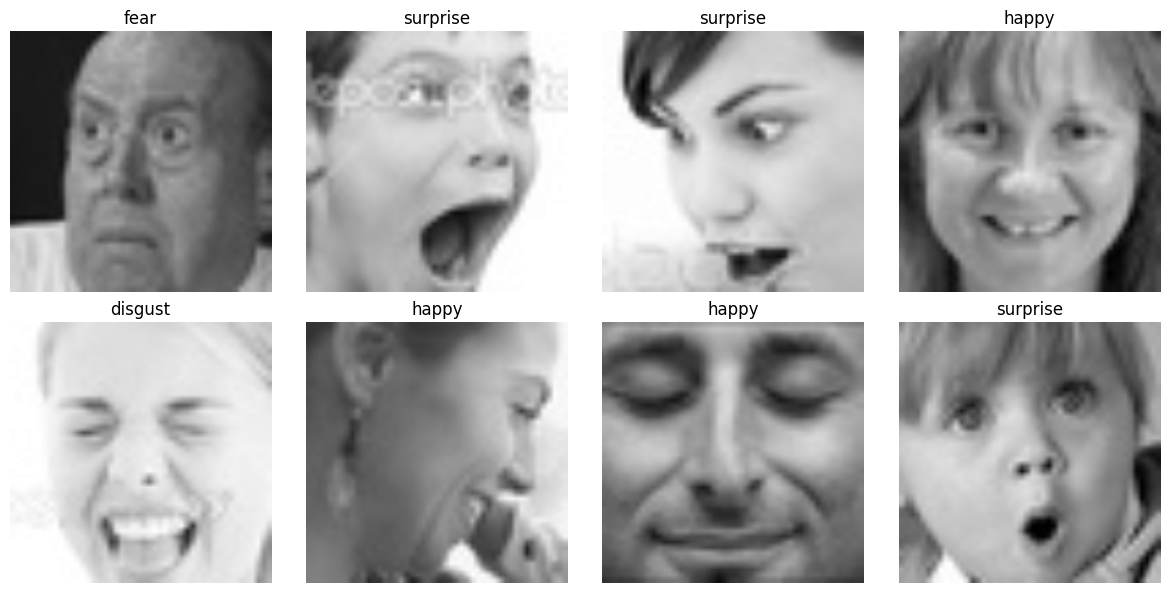

In [7]:
def denormalize(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_tensor = image_tensor.cpu() * std + mean
    return image_tensor.clamp(0, 1)

sample_images, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for idx in range(8):
    image = denormalize(sample_images[idx]).permute(1, 2, 0).numpy()
    label = class_names[sample_labels[idx].item()]
    axes[idx].imshow(image)
    axes[idx].set_title(label)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


## 7. Load Pretrained ResNet18

We start from a pretrained ResNet18 model so training converges faster than training from scratch.

In [8]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 8. Replace the Final Layer for 7 Emotion Classes

The original ImageNet classifier is replaced with a new output layer for our FER2013 classes.

In [9]:
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

print(model.fc)


Linear(in_features=512, out_features=7, bias=True)


## 9. Define Loss Function, Optimizer, and Training Loop

We use cross-entropy loss for multiclass classification and Adam for a simple first baseline.

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
EPOCHS = 3

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}


def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_training):
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            if is_training:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(dim=1)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (preds == labels).sum().item()
            total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_accuracy = running_correct / total_samples
    return epoch_loss, epoch_accuracy


## 10. Train for a Small First Run

We train for 3 epochs as a first baseline run and keep the best model based on validation accuracy.

In [11]:
best_model_wts = copy.deepcopy(model.state_dict())
best_val_accuracy = 0.0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_loss, train_accuracy = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_accuracy = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(f"  Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_wts = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_wts)
print(f"Best validation accuracy: {best_val_accuracy:.4f}")


Epoch 1/3


  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  Train Loss: 1.4483 | Train Accuracy: 0.4505
  Val Loss:   1.2737 | Val Accuracy:   0.5176
Epoch 2/3


  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  Train Loss: 1.0012 | Train Accuracy: 0.6428
  Val Loss:   1.2270 | Val Accuracy:   0.5487
Epoch 3/3


  0%|          | 0/171 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  Train Loss: 0.7104 | Train Accuracy: 0.7554
  Val Loss:   1.2510 | Val Accuracy:   0.5621
Best validation accuracy: 0.5621


## 11. Training History

The notebook tracks train loss, train accuracy, validation loss, and validation accuracy.

In [12]:
history


{'train_loss': [1.448304180602051, 1.0011738309912532, 0.7103843225857458],
 'train_accuracy': [0.45045703839122486,
  0.6427787934186472,
  0.7553930530164534],
 'val_loss': [1.2737065042768205, 1.2270477594302553, 1.2509974021595704],
 'val_accuracy': [0.5175983436853002, 0.5486542443064182, 0.562111801242236]}

## 12. Plot Training Curves

We save the training curves to the `outputs/` folder.

Task was destroyed but it is pending!
task: <Task pending name='Task-106' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-107' coro=<Kernel.shell_main() running at C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\.venv\Lib\site-packages\cycler\__init__.py:441: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for k in keys:
Task was destroyed but it is pending!
task: <Task pending name='Task-107' coro=<Kernel.shell_main() running at C:\Users\kevin\Study\HCDM - Term Pro

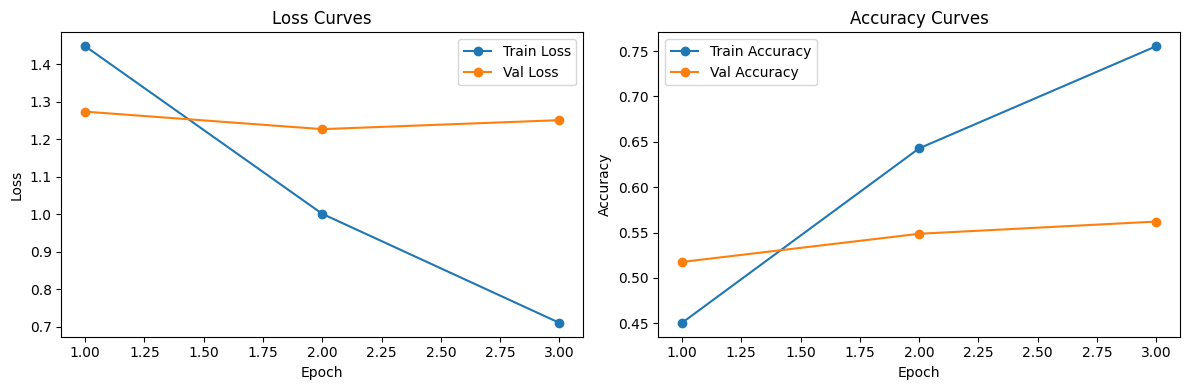

Saved training curves to: C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\outputs\training_curves.png


In [13]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="Val Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_accuracy"], marker="o", label="Train Accuracy")
axes[1].plot(epochs_range, history["val_accuracy"], marker="o", label="Val Accuracy")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(TRAINING_CURVES_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved training curves to: {TRAINING_CURVES_PATH}")


## 13. Evaluate on the Test Set

We use the best validation model for final test evaluation.

In [14]:
model.eval()

all_preds = []
all_labels = []
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        preds = outputs.argmax(dim=1)

        batch_size = labels.size(0)
        test_loss += loss.item() * batch_size
        test_correct += (preds == labels).sum().item()
        test_total += batch_size

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= test_total
test_accuracy = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


  0%|          | 0/185 [00:00<?, ?it/s]

Test Loss: 1.2955
Test Accuracy: 0.5541


## 14. Confusion Matrix and Classification Report

We compute and save both a confusion matrix image and a text classification report.

              precision    recall  f1-score   support

       angry       0.49      0.56      0.52       958
     disgust       0.28      0.66      0.39       111
        fear       0.56      0.27      0.36      1000
       happy       0.78      0.75      0.77      1000
     neutral       0.48      0.59      0.53      1000
         sad       0.42      0.49      0.46      1000
    surprise       0.79      0.67      0.73       831

    accuracy                           0.55      5900
   macro avg       0.54      0.57      0.54      5900
weighted avg       0.58      0.55      0.55      5900



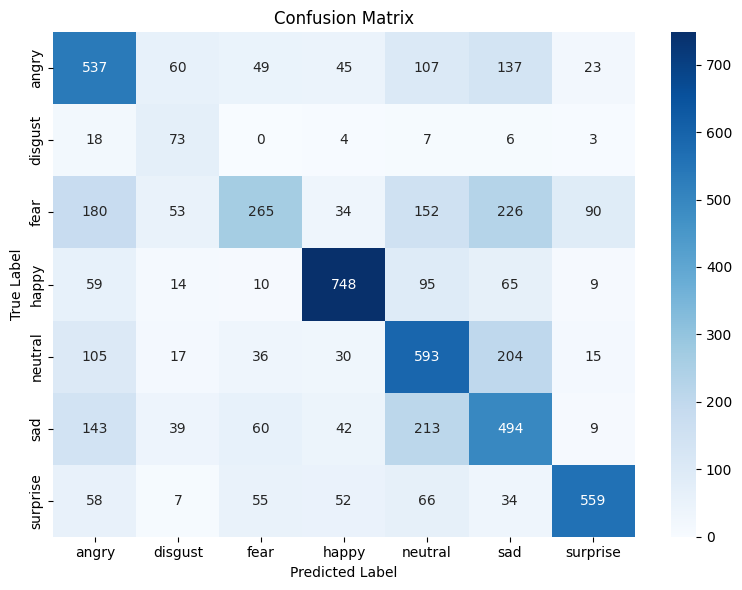

Saved confusion matrix to: C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\outputs\confusion_matrix.png
Saved classification report to: C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\outputs\classification_report.txt


In [15]:
cm = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=class_names)

print(report)

with open(CLASSIFICATION_REPORT_PATH, "w", encoding="utf-8") as file:
    file.write(report)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix to: {CONFUSION_MATRIX_PATH}")
print(f"Saved classification report to: {CLASSIFICATION_REPORT_PATH}")


## 15. Save the Trained Model

We save the best model weights to the `models/` folder.

In [16]:
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved model to: {MODEL_PATH}")


Saved model to: C:\Users\kevin\Study\HCDM - Term Project - Facial Emotion Detection\models\resnet18_fer2013.pth


## 16. Output Summary

Expected saved outputs after running the full notebook:
- `models/resnet18_fer2013.pth`
- `outputs/training_curves.png`
- `outputs/confusion_matrix.png`
- `outputs/classification_report.txt`